In [1]:
words = open('names.txt', 'r').read().splitlines()


In [2]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [3]:
len(words)

32034

In [4]:
min(len(w) for w in words)

2

In [5]:
max(len(w) for w in words)

15

In [6]:
b = {}
for w in words[:]:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) +1
        # print(ch1,ch2)

In [14]:
sorted(b.items(), key = lambda kv: -kv[1])

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5439),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2591),
 (('<S>', 'm'), 2539),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [15]:
def key_function(kv):
    return kv[1]

items = list(b.items())

decorated = []
for item in items:
    decorated.append((key_function(item), item))
print(decorated[:10])
decorated.sort(key=lambda pair: pair[0])

result = []
for _, item in decorated:
    result.append(item)

print(result[:10])

[(1531, (('<S>', 'e'), 1531)), (769, (('e', 'm'), 769)), (168, (('m', 'm'), 168)), (2591, (('m', 'a'), 2591)), (6640, (('a', '<E>'), 6640)), (394, (('<S>', 'o'), 394)), (619, (('o', 'l'), 619)), (2480, (('l', 'i'), 2480)), (269, (('i', 'v'), 269)), (911, (('v', 'i'), 911))]
[(('q', 'r'), 1), (('d', 'z'), 1), (('p', 'j'), 1), (('q', 'l'), 1), (('p', 'f'), 1), (('q', 'e'), 1), (('b', 'c'), 1), (('c', 'd'), 1), (('m', 'f'), 1), (('p', 'n'), 1)]


In [16]:
import torch

In [17]:
N = torch.zeros((27,27), dtype = torch.int32)


In [18]:
chars = sorted((list(set(''.join(words)))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi ['.'] = 0
itos = {i:s for s, i in stoi.items()}
# stoi ['<E>'] = 27

In [19]:
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [20]:
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [21]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1,ix2] += 1
chs

['.', 'z', 'z', 'y', 'z', 'x', '.']

In [117]:
N

tensor([[   0, 4410, 1306, 1542, 1690, 1531,  417,  669,  874,  591, 2422, 2963,
         1572, 2539, 1146,  394,  515,   92, 1639, 2055, 1308,   78,  376,  307,
          134,  535,  929],
        [6640,  556,  541,  470, 1042,  692,  134,  168, 2332, 1650,  175,  568,
         2528, 1634, 5439,   63,   82,   60, 3264, 1118,  687,  381,  834,  161,
          182, 2050,  435],
        [ 114,  321,   38,    1,   65,  655,    0,    0,   41,  217,    1,    0,
          103,    0,    4,  105,    0,    0,  842,    8,    2,   45,    0,    0,
            0,   83,    0],
        [  97,  815,    0,   42,    1,  551,    0,    2,  664,  271,    3,  316,
          116,    0,    0,  380,    1,   11,   76,    5,   35,   35,    0,    0,
            3,  104,    4],
        [ 516, 1303,    1,    3,  149, 1283,    5,   25,  118,  674,    9,    3,
           60,   30,   31,  378,    0,    1,  424,   29,    4,   92,   17,   23,
            0,  317,    1],
        [3983,  679,  121,  153,  384, 1271,   82,

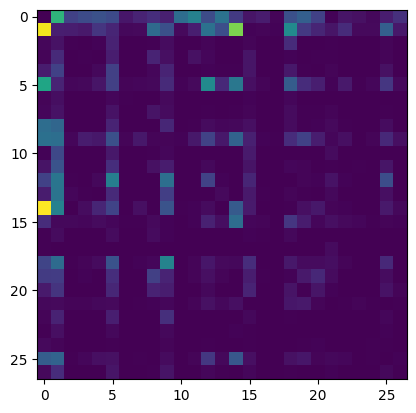

In [118]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(N)

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

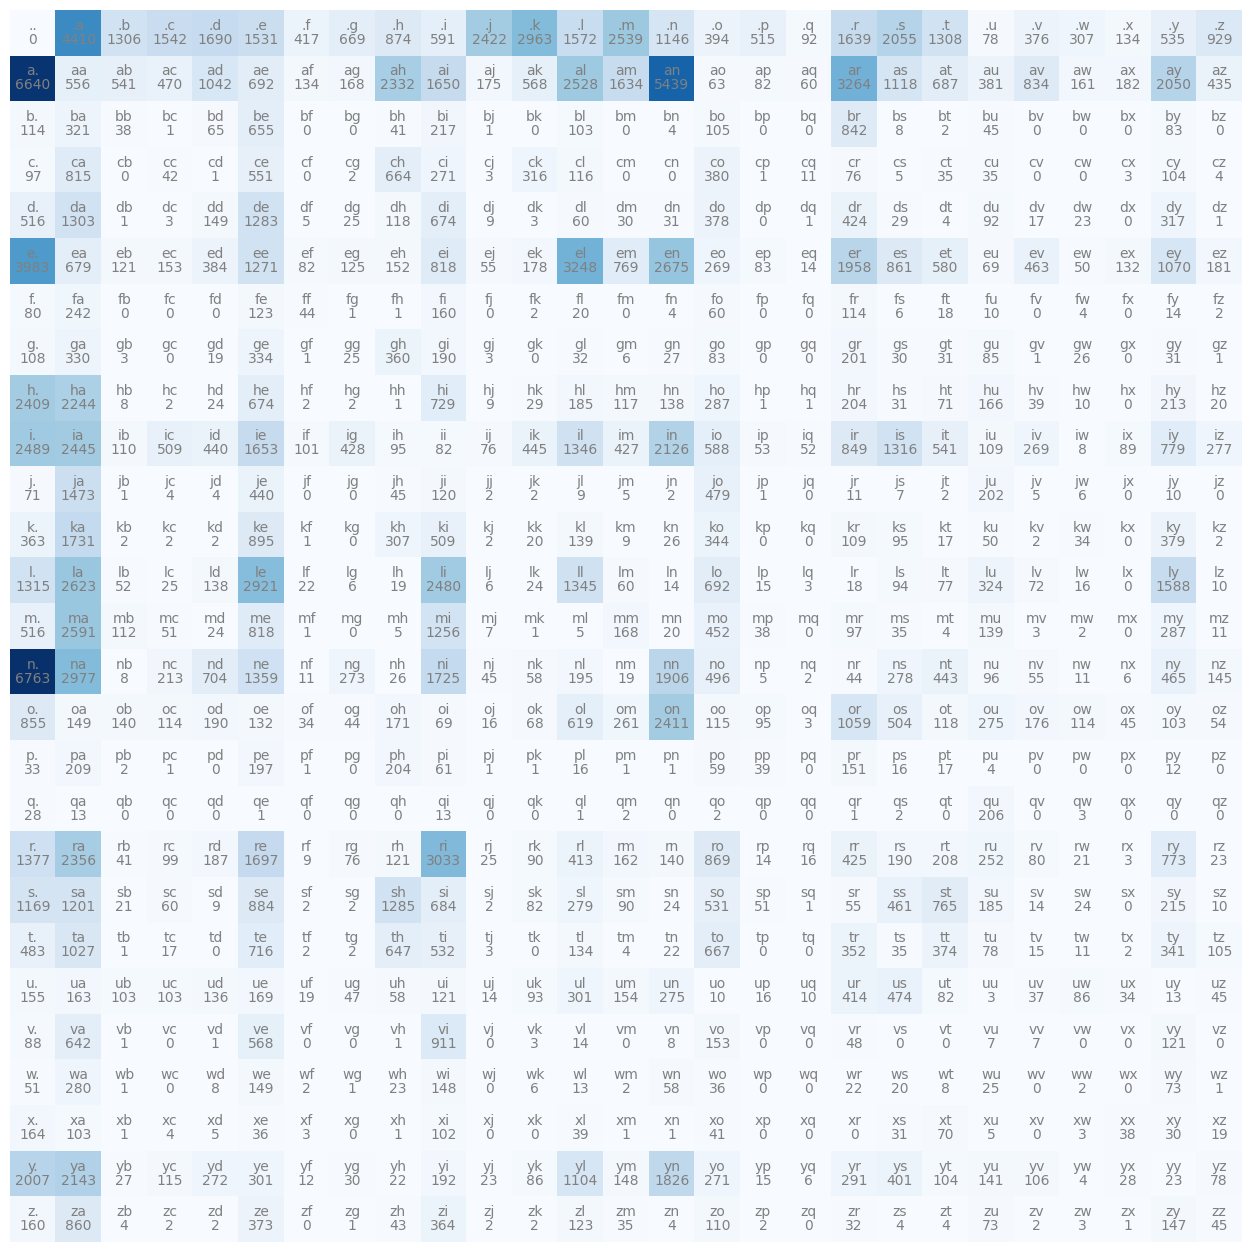

In [119]:
plt.figure(figsize=(16,16))
plt.imshow(N, cmap= 'Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha= "center", va = "bottom", color= "gray")
        plt.text(j,i, N[i, j].item(), ha= "center", va= "top", color= "gray")
plt.axis('off')

In [120]:
N[0,:].shape

torch.Size([27])

In [34]:
p = N[0].float()
p = p/p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0793, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [122]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples = 1, replacement=True, generator = g).item()
# print(ix)
itos[ix]

'c'

In [33]:
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator = g)
p = p/p.sum()
p

tensor([0.6064, 0.3033, 0.0903])

In [124]:
# g = torch.Generator().manual_seed(2147483647)

for i in range(10):
    ix = 0
    out = []
    while True:
        p = N[ix].float()
        p = p/p.sum()
        ix = torch.multinomial(p, num_samples = 1, generator = g).item()
        # print(itos[ix])
        out.append(itos[ix])
        if ix ==0:
            break
    print(''.join(out))

yayda.
sho.
pemppa.
etolelormaira.
sramon.
me.
toil.
jor.
atonike.
llaman.


In [125]:
# g = torch.Generator().manual_seed(2147483647)

for i in range(10):
    ix = 0
    out = []
    while True:
        p = torch.ones(27)
        p = p/p.sum()
        ix = torch.multinomial(p, num_samples = 1, generator = g).item()
        # print(itos[ix])
        out.append(itos[ix])
        if ix ==0:
            break
    print(''.join(out))

sjvaz.
ohgqzrcixkdyxytlaijuks.
evftxyrrqbbwfmzplbaynjtstysyfadrplcvtx.
uheqoemgrjkugvmrexsnpinjp.
sfnatn.
.
jjcjnixqnbbyiidtjbvksmm.
ymgdsataokfrx.
apmrnasa.
hxuk.


In [126]:
# g = torch.Generator().manual_seed(2147483647)

for i in range(10):
    ix = 0
    out = []
    while True:
        p = N[ix].float()
        p = torch.softmax(p, dim = 0)
        ix = torch.multinomial(p, num_samples = 1, generator = g).item()
        # print(itos[ix])
        out.append(itos[ix])
        if ix ==0:
            break
    print(''.join(out))

a.
a.
a.
a.
a.
a.
a.
a.
a.
a.


In [27]:
P = torch.rand(27,27)
for i in range(27):
    for j in range(27):
        P[i,j]= N[i,j].float()/N[i].sum()
P

tensor([[0.0000e+00, 1.3767e-01, 4.0769e-02, 4.8136e-02, 5.2756e-02, 4.7793e-02,
         1.3017e-02, 2.0884e-02, 2.7284e-02, 1.8449e-02, 7.5607e-02, 9.2495e-02,
         4.9073e-02, 7.9260e-02, 3.5774e-02, 1.2299e-02, 1.6077e-02, 2.8719e-03,
         5.1164e-02, 6.4151e-02, 4.0832e-02, 2.4349e-03, 1.1738e-02, 9.5836e-03,
         4.1831e-03, 1.6701e-02, 2.9000e-02],
        [1.9595e-01, 1.6408e-02, 1.5965e-02, 1.3870e-02, 3.0750e-02, 2.0421e-02,
         3.9544e-03, 4.9578e-03, 6.8819e-02, 4.8693e-02, 5.1644e-03, 1.6762e-02,
         7.4603e-02, 4.8221e-02, 1.6051e-01, 1.8592e-03, 2.4199e-03, 1.7706e-03,
         9.6323e-02, 3.2993e-02, 2.0274e-02, 1.1244e-02, 2.4612e-02, 4.7512e-03,
         5.3709e-03, 6.0497e-02, 1.2837e-02],
        [4.3100e-02, 1.2136e-01, 1.4367e-02, 3.7807e-04, 2.4575e-02, 2.4764e-01,
         0.0000e+00, 0.0000e+00, 1.5501e-02, 8.2042e-02, 3.7807e-04, 0.0000e+00,
         3.8941e-02, 0.0000e+00, 1.5123e-03, 3.9698e-02, 0.0000e+00, 0.0000e+00,
         3.1834e-

In [28]:
P[0].sum()

tensor(1.0000)

In [29]:
P = N.float()
P.sum(1).shape

torch.Size([27])

In [30]:
P.sum(1, keepdim=True).shape

torch.Size([27, 1])

In [31]:
P= P/P.sum(1,keepdim=True)

In [35]:
print(p[0].sum().item())
P[0]

0.0


tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0793, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [36]:
for i in range(10):
    out = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples = 1, generator = g).item()
        out.append(itos[ix])
        if ix ==0:
            break
    print(''.join(out))

yayda.
sho.
pemppa.
etolelormaira.
sramon.
me.
toil.
jor.
atonike.
llaman.


In [37]:
for w in words[:2]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        # print(ix1, ix2)
        p = P[ix1, ix2]
        print(F'{ch1}{ch2} Prob: {p:.4f}')


.e Prob: 0.0478
em Prob: 0.0377
mm Prob: 0.0253
ma Prob: 0.3900
a. Prob: 0.1960
.o Prob: 0.0123
ol Prob: 0.0780
li Prob: 0.1777
iv Prob: 0.0152
vi Prob: 0.3541
ia Prob: 0.1381
a. Prob: 0.1960


In [44]:
log_likelihood = 0.0
n= 0
for w in words[:2]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        print(ix1, ix2)
        n+=1
        p = P[ix1, ix2]
        print(p)
        log_prob = torch.log(p)
        print(log_prob)
        log_likelihood += log_prob
        print(log_likelihood)
        # print(F'{ch1}{ch2} Prob: {p:.4f} LogProb: {log_prob:.4f}')

print(f'Log Likelihood of first two words: {log_likelihood:.4f}')
nll = -log_likelihood
print(f'Negative Log Likelihood of first two words: {nll:.4f}')
print(f'Average NLL per character: {nll/n:.4f}')

0 5
tensor(0.0478)
tensor(-3.0409)
tensor(-3.0409)
5 13
tensor(0.0377)
tensor(-3.2793)
tensor(-6.3202)
13 13
tensor(0.0253)
tensor(-3.6774)
tensor(-9.9976)
13 1
tensor(0.3900)
tensor(-0.9415)
tensor(-10.9391)
1 0
tensor(0.1960)
tensor(-1.6299)
tensor(-12.5690)
0 15
tensor(0.0123)
tensor(-4.3982)
tensor(-16.9672)
15 12
tensor(0.0780)
tensor(-2.5508)
tensor(-19.5180)
12 9
tensor(0.1777)
tensor(-1.7279)
tensor(-21.2458)
9 22
tensor(0.0152)
tensor(-4.1867)
tensor(-25.4326)
22 9
tensor(0.3541)
tensor(-1.0383)
tensor(-26.4708)
9 1
tensor(0.1381)
tensor(-1.9796)
tensor(-28.4505)
1 0
tensor(0.1960)
tensor(-1.6299)
tensor(-30.0804)
Log Likelihood of first two words: -30.0804
Negative Log Likelihood of first two words: 30.0804
Average NLL per character: 2.5067


In [139]:
for w in ['manjil']:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        # print(ix1, ix2)
        p = P[ix1, ix2]
        print(F'{ch1}{ch2} Prob: {p:.4f}')

.m Prob: 0.0793
ma Prob: 0.3900
an Prob: 0.1605
nj Prob: 0.0025
ji Prob: 0.0414
il Prob: 0.0760
l. Prob: 0.0942


In [144]:
log_likelihood = 0.0
n= 0
for w in ['manjilqq']:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        # print(ix1, ix2)
        n+=1
        p = P[ix1, ix2]
        log_prob = torch.log(p)
        log_likelihood += log_prob
        print(F'{ch1}{ch2} Prob: {p:.4f}')

print(f'Log Likelihood of first two words: {log_likelihood:.4f}')
nll = -log_likelihood
print(f'Negative Log Likelihood of first two words: {nll:.4f}')
print(f'Average NLL per character: {nll/n:.4f}')

.m Prob: 0.0793
ma Prob: 0.3900
an Prob: 0.1605
nj Prob: 0.0025
ji Prob: 0.0414
il Prob: 0.0760
lq Prob: 0.0002
qq Prob: 0.0000
q. Prob: 0.1029
Log Likelihood of first two words: -inf
Negative Log Likelihood of first two words: inf
Average NLL per character: inf


In [153]:
P = N.float()+1
P.shape
P= P/P.sum(1, keepdim=True)

In [154]:
log_likelihood = 0.0
n= 0
for w in ['manjilqq']:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        # print(ix1, ix2)
        n+=1
        p = P[ix1, ix2]
        log_prob = torch.log(p)
        log_likelihood += log_prob
        print(F'{ch1}{ch2} Prob: {p:.4f}')

print(f'Log Likelihood of first two words: {log_likelihood:.4f}')
nll = -log_likelihood
print(f'Negative Log Likelihood of first two words: {nll:.4f}')
print(f'Average NLL per character: {nll/n:.4f}')

.m Prob: 0.0792
ma Prob: 0.3886
an Prob: 0.1604
nj Prob: 0.0025
ji Prob: 0.0413
il Prob: 0.0760
lq Prob: 0.0003
qq Prob: 0.0033
q. Prob: 0.0970
Log Likelihood of first two words: -33.2564
Negative Log Likelihood of first two words: 33.2564
Average NLL per character: 3.6952


In [162]:
xs , ys = [], []

for w in words[:1]:
    chs = ['.']+list(w)+['.']
    for ch1,ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs  = torch.tensor(xs)
ys  = torch.tensor(ys)

In [163]:
print(xs)
print(ys)


tensor([ 0,  5, 13, 13,  1])
tensor([ 5, 13, 13,  1,  0])


In [165]:
import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes = 27).float()
print(xenc.shape)
print(xenc.dtype)

torch.Size([5, 27])
torch.float32


In [166]:
W = torch.randn(27,1)

In [168]:
xenc @ W

tensor([[-0.5616],
        [-1.3248],
        [ 1.0409],
        [ 1.0409],
        [ 0.9025]])

In [172]:
W = torch.randn(27,27)
(xenc@W)

tensor([[-1.2306,  0.2273,  0.8802, -1.0252, -0.5280, -0.7598,  0.3391, -0.7794,
         -1.1022,  0.2236, -1.2299, -0.9402, -0.6012, -0.2540,  2.3156, -0.9139,
          1.1411,  2.1218, -0.6904, -0.2768, -1.6896,  1.9398, -1.7983,  0.9466,
         -0.1101,  1.7321,  0.2262],
        [ 0.1602,  0.6784,  0.0888,  1.0684,  0.5295,  1.6769,  0.7125, -0.8698,
         -1.7665,  0.8460,  0.2704, -0.3825, -1.7729, -0.1199, -0.7883, -0.1849,
          0.9729,  1.3341,  1.3450,  0.5362, -0.1239,  0.5625,  0.8285, -0.9791,
          1.9977, -0.8171, -0.7163],
        [-0.0795,  0.2534,  1.3419,  0.3851, -1.1554,  0.8935,  0.4789, -0.9932,
          0.4053, -0.9007, -1.3461,  1.3342,  0.3240, -0.5146,  2.6429, -0.1205,
          0.1494,  0.3388,  0.8906,  0.2010,  1.5142,  0.1007,  0.2929, -0.8471,
         -0.8687, -0.3097, -0.2385],
        [-0.0795,  0.2534,  1.3419,  0.3851, -1.1554,  0.8935,  0.4789, -0.9932,
          0.4053, -0.9007, -1.3461,  1.3342,  0.3240, -0.5146,  2.6429, -0.1205

In [176]:
logits = xenc @ W
counts = logits.exp()
prob = counts/ counts.sum(1, keepdim=True)
prob

tensor([[0.0056, 0.0242, 0.0466, 0.0069, 0.0114, 0.0090, 0.0271, 0.0089, 0.0064,
         0.0242, 0.0056, 0.0075, 0.0106, 0.0150, 0.1956, 0.0077, 0.0605, 0.1612,
         0.0097, 0.0146, 0.0036, 0.1344, 0.0032, 0.0498, 0.0173, 0.1092, 0.0242],
        [0.0239, 0.0401, 0.0223, 0.0593, 0.0346, 0.1090, 0.0415, 0.0085, 0.0035,
         0.0475, 0.0267, 0.0139, 0.0035, 0.0181, 0.0093, 0.0169, 0.0539, 0.0773,
         0.0782, 0.0348, 0.0180, 0.0358, 0.0466, 0.0077, 0.1502, 0.0090, 0.0100],
        [0.0182, 0.0254, 0.0754, 0.0290, 0.0062, 0.0482, 0.0318, 0.0073, 0.0296,
         0.0080, 0.0051, 0.0749, 0.0273, 0.0118, 0.2771, 0.0175, 0.0229, 0.0277,
         0.0480, 0.0241, 0.0896, 0.0218, 0.0264, 0.0085, 0.0083, 0.0145, 0.0155],
        [0.0182, 0.0254, 0.0754, 0.0290, 0.0062, 0.0482, 0.0318, 0.0073, 0.0296,
         0.0080, 0.0051, 0.0749, 0.0273, 0.0118, 0.2771, 0.0175, 0.0229, 0.0277,
         0.0480, 0.0241, 0.0896, 0.0218, 0.0264, 0.0085, 0.0083, 0.0145, 0.0155],
        [0.0072, 0.0076,

In [177]:
prob[0].sum()

tensor(1.)

In [179]:
torch.arange(5)

tensor([0, 1, 2, 3, 4])

In [182]:
loss = -prob[torch.arange(5), ys].log().mean()
loss

tensor(4.3546)

In [224]:
W = torch.randn((27,27), requires_grad=True)

In [301]:
#Forrward pass


xenc = F.one_hot(xs, num_classes = 27).float()
logits = xenc @ W
counts = logits.exp()
prob = counts/ counts.sum(1, keepdim=True)
loss = -prob[torch.arange(5), ys].log().mean()
loss

tensor(2.8177, grad_fn=<NegBackward0>)

In [302]:
#Backward Pass
W.grad = None
loss.backward()

In [303]:
print(W.shape)
print(W.grad.shape)

torch.Size([27, 27])
torch.Size([27, 27])


In [304]:
W.data += -0.1*W.grad

In [342]:
len(words)

32034

In [351]:
xs, ys = [], []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print("Number of element: ", num)

g = torch.Generator().manual_seed(2147483647+1)
W = torch.randn((27,27), generator=g, requires_grad=True)

Number of element:  228153


In [352]:
ys

tensor([ 5, 13, 13,  ..., 26, 24,  0])

In [353]:
xs

tensor([ 0,  5, 13,  ..., 25, 26, 24])

In [357]:

for k in range(110):
    
    #forward
    xenc = F.one_hot(xs, num_classes=27).float()
    logits = xenc @ W
    counts = logits.exp()
    prob = counts / counts.sum(1,keepdim=True).float()
    loss = -prob[torch.arange(xenc.shape[0]),ys].log().mean()
    
    #
    W.grad = None
    loss.backward()
    
    W.data += -10*W.grad
    print(loss.item())


2.4936985969543457
2.493525266647339
2.4933536052703857
2.4931833744049072
2.493014097213745
2.4928462505340576
2.4926798343658447
2.4925143718719482
2.4923503398895264
2.492187738418579
2.492025852203369
2.491865634918213
2.4917068481445312
2.491548776626587
2.491391658782959
2.491236448287964
2.491081953048706
2.490928888320923
2.490776538848877
2.4906256198883057
2.490475654602051
2.4903266429901123
2.4901790618896484
2.490032434463501
2.489886999130249
2.4897422790527344
2.4895989894866943
2.4894561767578125
2.4893150329589844
2.4891743659973145
2.4890353679656982
2.488896608352661
2.4887592792510986
2.4886231422424316
2.488487482070923
2.4883530139923096
2.4882192611694336
2.488086700439453
2.487955093383789
2.4878242015838623
2.487694501876831
2.487565279006958
2.4874372482299805
2.4873099327087402
2.4871838092803955
2.48705792427063
2.486933469772339
2.486809730529785
2.486686944961548
2.486564874649048
2.4864437580108643
2.486323356628418
2.486203670501709
2.4860846996307373
2.

In [393]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix = 0
    while True:
        p = P[ix]
        # print(i,"th pass")
        # print(p.sum())
        ix = torch.multinomial(p, generator=g, replacement=True, num_samples=1).item()
        # print(ix)
        out.append(itos[ix])
        if ix ==0:
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.


In [392]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
    out = []
    ix = 0
    while True:
        xenc = F.one_hot(torch.tensor([ix]), num_classes = 27).float()
        logits = xenc @ W
        counts = logits.exp()
        p = counts/counts.sum(1, keepdim=True)

        ix = torch.multinomial(p, generator=g, replacement=True, num_samples=1).item()
        # print(ix)
        out.append(itos[ix])
        # print(out)
        if ix ==0:
            break
    print(''.join(out))

cexze.
momasurailezityha.
konimittain.
llayn.
ka.


In [390]:
F.one_hot(torch.tensor([8]), num_classes = 27).float()

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [362]:
W[ix].sum()

tensor(-3.8181, grad_fn=<SumBackward0>)